## Heart Disease Prediction using Machine Learning: Comparative Model Analysis and Risk Assessment

### Problem Statement

Heart disease is one of the leading causes of mortality worldwide, and early detection is critical for effective treatment. However, identifying high-risk individuals based on multiple clinical parameters can be complex.

This project aims to develop a machine learning-based system that can analyze patient clinical data and predict the likelihood of heart disease, while also identifying the most effective model through comparative analysis.

### Objective

- To build a machine learning model for heart disease prediction using clinical data  
- To compare multiple models using Accuracy, F1-score, and ROC-AUC  
- To identify the best-performing model  
- To analyze important clinical features influencing prediction  
- To demonstrate the use of machine learning as a decision-support tool in healthcare  

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Loading the Dataset

In [3]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### Statistical summary

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Missing values

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Target distribution

In [7]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

### Target distribution bar plot

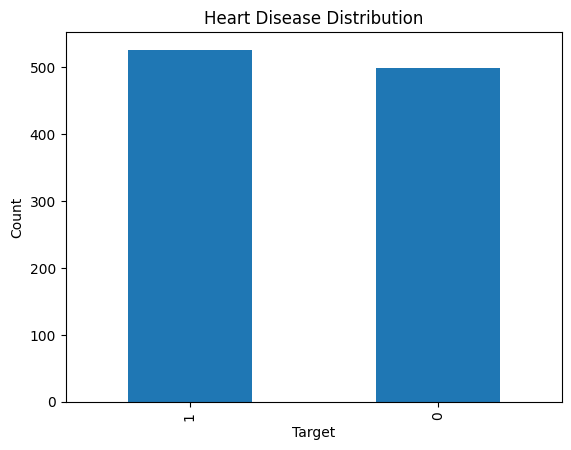

In [8]:
df['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

### Defining X and y

In [9]:
X = df.drop('target', axis=1)
y = df['target']

### Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scaling

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression

In [12]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

### Decision Tree

In [13]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

### Random Forest

In [14]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### SVM

In [15]:
svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

### XGBoost

In [16]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

### Logistic Regression evaluation

In [17]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7951219512195122
[[73 29]
 [13 90]]
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



### Decision Tree evaluation

In [18]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Random Forest evaluation

In [19]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### SVM evaluation

In [20]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8878048780487805
[[85 17]
 [ 6 97]]
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



### XGBoost evaluation

In [21]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Accuracy comparison table

In [22]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_svm, acc_xgb]
}).sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
1        Decision Tree  0.985366
4              XGBoost  0.985366
2        Random Forest  0.985366
3                  SVM  0.887805
0  Logistic Regression  0.795122


### Accuracy comparison chart

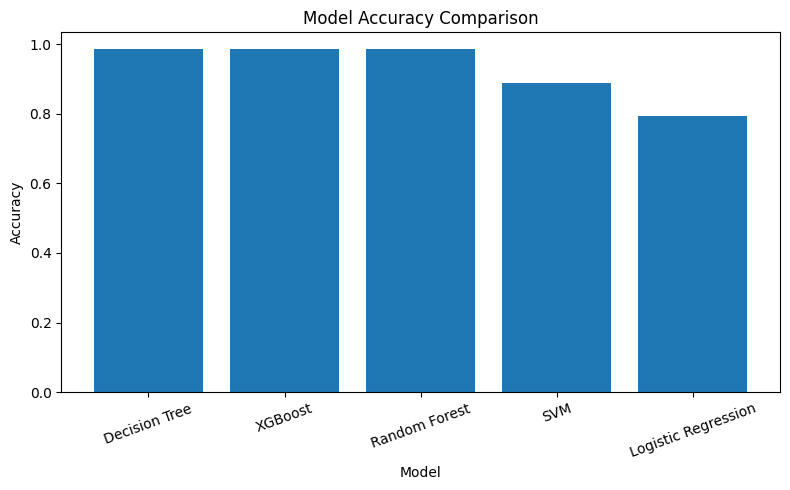

In [23]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### F1-score comparison table

In [24]:
f1_lr = f1_score(y_test, y_pred_lr)
f1_dt = f1_score(y_test, y_pred_dt)
f1_rf = f1_score(y_test, y_pred_rf)
f1_svm = f1_score(y_test, y_pred_svm)
f1_xgb = f1_score(y_test, y_pred_xgb)

f1_results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost'],
    'F1_score': [f1_lr, f1_dt, f1_rf, f1_svm, f1_xgb]
}).sort_values(by='F1_score', ascending=False)

print(f1_results_df)

                 Model  F1_score
1        Decision Tree  0.985222
4              XGBoost  0.985222
2        Random Forest  0.985222
3                  SVM  0.894009
0  Logistic Regression  0.810811


### F1-score comparison chart

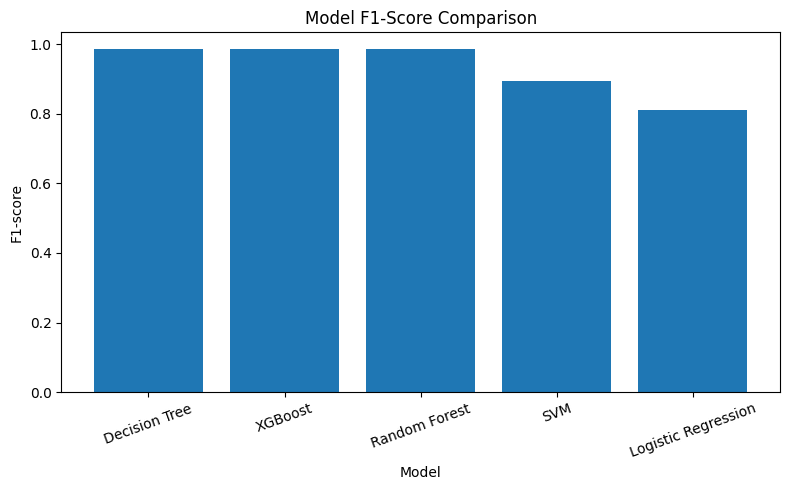

In [25]:
plt.figure(figsize=(8,5))
plt.bar(f1_results_df['Model'], f1_results_df['F1_score'])
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### ROC-AUC comparison table

In [26]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

auc_results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM', 'XGBoost'],
    'ROC_AUC': [auc_dt, auc_rf, auc_svm, auc_xgb]
}).sort_values(by='ROC_AUC', ascending=False)

print(auc_results_df)

           Model   ROC_AUC
1  Random Forest  1.000000
3        XGBoost  0.989435
0  Decision Tree  0.985437
2            SVM  0.963164


### ROC-AUC comparison chart

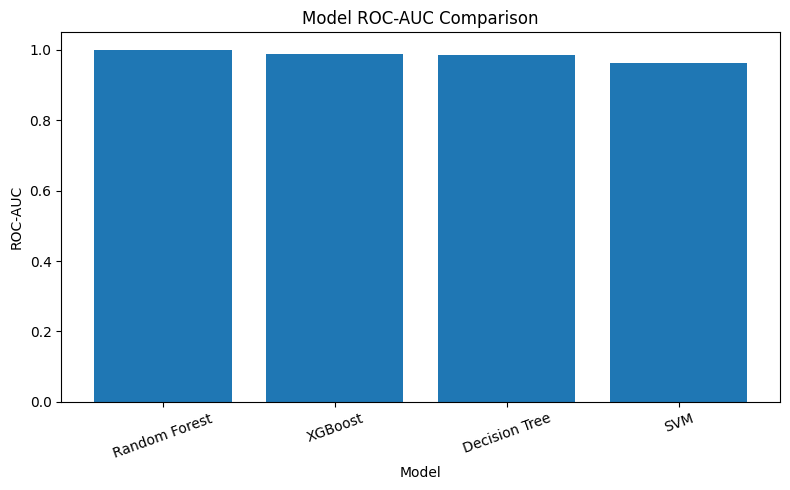

In [27]:
plt.figure(figsize=(8,5))
plt.bar(auc_results_df['Model'], auc_results_df['ROC_AUC'])
plt.title('Model ROC-AUC Comparison')
plt.xlabel('Model')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Final selected model

In [28]:
final_model_name = auc_results_df.iloc[0]['Model']
print("Final Selected Model:", final_model_name)

Final Selected Model: Random Forest


### ROC curve for final model

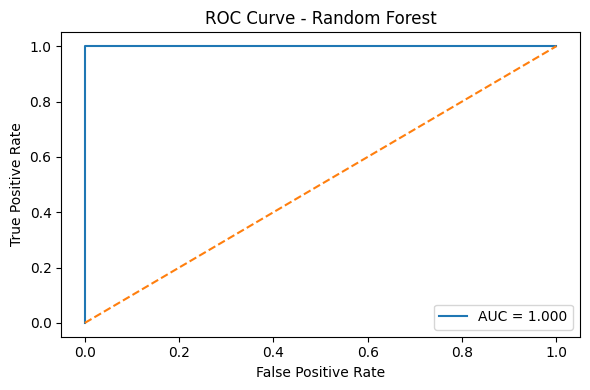

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance table for final model

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


### Feature importance chart for final model

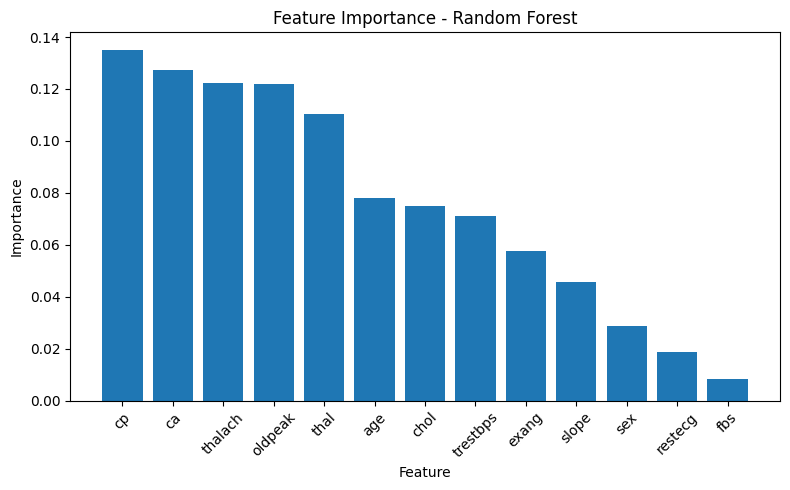

In [31]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation of Feature Importance

The feature importance analysis shows that some clinical parameters contribute more strongly to heart disease prediction than others. In this project, chest pain type (`cp`) emerged as one of the most influential factors.

This is biologically meaningful because chest pain is one of the most common symptoms associated with cardiovascular disorders, especially coronary artery disease and angina. Other important features such as cholesterol (`chol`), maximum heart rate achieved (`thalach`), exercise-induced angina (`exang`), and oldpeak are also clinically relevant because they reflect cardiac stress, blood flow condition, and exercise response.

### Sample Prediction for a New Patient

In [32]:
sample_patient = pd.DataFrame([{
    'age': 52,
    'sex': 1,
    'cp': 2,
    'trestbps': 130,
    'chol': 250,
    'fbs': 0,
    'restecg': 1,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 1.5,
    'slope': 1,
    'ca': 0,
    'thal': 2
}])

sample_patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,2,130,250,0,1,150,0,1.5,1,0,2


### Scaling the sample patient

In [33]:
sample_patient_scaled = scaler.transform(sample_patient)

### Predicting the class for the sample patient

In [34]:
sample_prediction = rf_model.predict(sample_patient_scaled)
print("Predicted Class:", sample_prediction[0])

Predicted Class: 1


### Predicting the probability for the sample patient

In [35]:
sample_probability = rf_model.predict_proba(sample_patient_scaled)
print("Prediction Probabilities:", sample_probability)

Prediction Probabilities: [[0.19 0.81]]


### Showing heart disease risk percentage

In [36]:
heart_disease_risk = sample_probability[0][1] * 100
print(f"Predicted Risk of Heart Disease: {heart_disease_risk:.2f}%")

Predicted Risk of Heart Disease: 81.00%


### Converting risk into category

In [37]:
if heart_disease_risk < 30:
    print("Risk Level: Low Risk")
elif heart_disease_risk < 70:
    print("Risk Level: Moderate Risk")
else:
    print("Risk Level: High Risk")

Risk Level: High Risk


### Readable interpretation

In [38]:
if sample_prediction[0] == 1:
    print("Final Interpretation: The model predicts that the patient is likely to have heart disease.")
else:
    print("Final Interpretation: The model predicts that the patient is unlikely to have heart disease.")

Final Interpretation: The model predicts that the patient is likely to have heart disease.


### Real-World Significance

This project demonstrates how machine learning can be applied in the healthcare domain for early prediction of heart disease risk. By analyzing clinical parameters such as chest pain type, cholesterol level, blood pressure, and heart rate response, the system can assist in identifying high-risk patients.

Such a model can be used as a preliminary screening tool in hospitals or clinics, helping doctors prioritize patients who may require further diagnostic testing. This can reduce diagnosis time and improve early intervention.

### Practical Use Case

In a real-world scenario, a patient’s medical data can be input into the system, and the trained model can predict the likelihood of heart disease along with a probability score.

This can help:
- Doctors in initial screening
- Hospitals in prioritizing high-risk patients
- Healthcare systems in reducing workload

### Biological Interpretation of Results

The model identified chest pain type (`cp`) as one of the most important features. This is biologically significant because chest pain is a primary symptom associated with coronary artery disease and reduced blood flow to the heart.

Other features such as cholesterol (`chol`), maximum heart rate (`thalach`), and exercise-induced angina (`exang`) also play important roles, as they reflect cardiovascular health, oxygen demand, and cardiac stress response.

Thus, the model’s findings align with known medical knowledge, making the predictions clinically meaningful.

### Limitations

- The model is trained on a specific dataset and may not generalize to all populations
- It does not include all possible biological or genetic factors
- It should not replace clinical diagnosis, only assist it
- More real-world data validation is required

### Future Scope

- Integration into a web or mobile application for real-time use
- Use of larger and more diverse medical datasets
- Addition of explainable AI techniques for better interpretability
- Deployment as a clinical decision-support system

### Key Findings

- Random Forest achieved the best overall performance among all models  
- Chest pain type (cp) was identified as the most influential feature  
- Probability-based prediction provides better clinical insight than binary output  
- The model can be used as an early screening tool for heart disease risk  

### Conclusion

In this project, multiple machine learning models were developed and evaluated for heart disease prediction using clinical data. The models were compared using Accuracy, F1-score, and ROC-AUC to ensure reliable and balanced evaluation.

Among all models, Random Forest performed the best, demonstrating strong predictive capability. Feature importance analysis showed that chest pain type is a key factor influencing prediction, aligning with clinical understanding.

This project highlights how machine learning can support early detection and risk assessment of heart disease, acting as a useful decision-support tool in healthcare.